# Задание 1. Dataset и Dataloader
* Скачайте данные и расположите их по пути `data/faces/..`
* Напишите реализацию загрузчика картинок для архивных картинок и новых фото, также трансформации к ним. На вход он должен принимать путь до директории с фото и необходимые трансформации, объединённые в единый пайплайн, а возвращать — сами фото и пути к ним. 
* Директории с фото содержат только расширения файлов .jpg, .PNG. 
* В качестве рабочей модели используйте `tf_efficientnet_b0`. Чтобы обратиться к её конфигу без инициализации самой модели, используйте метод: 
  * `cfg = timm.get_pretrained_cfg(model_name)`.
* Далее обращайтесь к необходимым атрибутам через `cfg.attribute`. 
* Соберите трансформации для картинок в порядке: масштабирование → перевод в тензор → нормализация.
* Переопределите методы `__len__`, `__getitem__` и добавьте вызов трансформаций в последний, проинициализируйте датасеты и Dataloader для новых и архивных фото.

In [35]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from PIL import Image
import timm

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torchvision.transforms as T

In [27]:
class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # считываем пути до фото
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir)
                          if f.endswith(('.jpg', '.PNG'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        # применяем трансформацию
        if self.transform:
            image = self.transform(image)

        return image, img_path

In [38]:
model_name = 'tf_efficientnet_b0'
cfg = timm.get_pretrained_cfg(model_name)

for el in re.sub(r", (?=[A-Za-z])", "; ", str(cfg).split('PretrainedCfg(')[1].strip(') ')).split('; '):
    print(el)

url='https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b0_ns-c0e6a31c.pth'
file=None
state_dict=None
hf_hub_id='timm/tf_efficientnet_b0.ns_jft_in1k'
hf_hub_filename=None
source=None
architecture='tf_efficientnet_b0'
tag='ns_jft_in1k'
custom_load=False
input_size=(3, 224, 224)
test_input_size=None
min_input_size=None
fixed_input_size=False
interpolation='bicubic'
crop_pct=0.875
test_crop_pct=None
crop_mode='center'
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
num_classes=1000
label_offset=None
label_names=None
label_descriptions=None
pool_size=(7, 7)
test_pool_size=None
first_conv='conv_stem'
classifier='classifier'
license='apache-2.0'
description=None
origin_url=None
paper_name=None
paper_ids=None
notes=None


In [29]:
# формируем трансформации для фото
transform = T.Compose([
    T.Resize(cfg.input_size[1:]),
    T.ToTensor(),
    T.Normalize(mean=cfg.mean,
                std=cfg.std)
])

  
# Создаём DataLoader для проверенных и новых изображений
db_dataset = FaceDataset('../data/faces/db', transform=transform)
new_dataset = FaceDataset('../data/faces/new', transform=transform)

db_loader = DataLoader(db_dataset, batch_size=2)        #, num_workers=2)  # с ненулевым num_workers выдает ошибку 
new_loader = DataLoader(new_dataset, batch_size=2)      #, num_workers=2)  # завершения итератора на моем десктопе

# Задание 2. Расчёт эмбеддингов картинок
* Инициализируйте модель, используйте предобученный вариант, возвращающий только 2 последних расчётных признака. 
* Допишите функцию расчёта эмбеддингов get_embeddings: 
  * она должна принимать на вход модель и загрузчик данных. 
  * В качестве эмбеддингов картинки возвращайте конкатенированные 2 последних признака модели `tf_efficientnet_b0` с использованием `avg_pool2d` для агрегации значений. 
  * Рассчитайте эмбеддинги всех фото и визуализируйте размерность эмбеддингов новых фото (визуализация и сохранение уже в прекоде). 
* Задайте аргументы `features_only` и `out_indices` при инициализации модели.
* При расчёте эмбеддингов примените `avg_pool2d` к каждому из двух выходных признаков модели. 
* В качестве аргумента `kernel_size` используйте кортеж из последних размерностей тензоров. 
* Конкатенируйте получившиеся тензоры, размерность финального тензора должна составить batch_size × (feature_1_dim + feature_2_dim).
* Чтобы убрать единичные размерности из тензора, используйте функцию squeeze(), которая принимает на вход индексы размерностей для сжатия.

In [30]:
def get_embeddings(loader, model):
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    
    embeddings = []
    paths = []
    with torch.no_grad():
        # итерируемся по батчам
        for images, batch_paths in loader:
            images = images.to(device)
            features = model(images)

            # используем пуллинг для агрегации и конкатенируем
            features = torch.cat([F.avg_pool2d(x, (x.size(-2), x.size(-1))) for x in features], dim=1).squeeze((-1, -2))

            embeddings.append(features.cpu())
            paths.extend(batch_paths)
            images = images.to("cpu")

    model.to("cpu")
    return torch.cat(embeddings, dim=0), paths

In [31]:
model = timm.create_model(model_name, 
                          pretrained=True, 
                          features_only=True, 
                          out_indices=[3,4])
model.eval()

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


EfficientNetFeatures(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): B

In [32]:
# Получаем эмбеддинги для проверенных и новых изображений
db_embeddings, db_paths = get_embeddings(db_loader, model)
new_embeddings, new_paths = get_embeddings(new_loader, model)

# Опционально сохраним для переиспользования
torch.save(db_embeddings, f="../data/faces/db_embeddings.pt")
torch.save(new_embeddings, f="../data/faces/new_embeddings.pt")

file_path = '../data/faces/new_paths'
np.save(file_path, np.array(new_paths))

print(new_embeddings.shape) 

torch.Size([9, 432])


# Задание 3. Поиск невалидных фотографий
Допишите функцию find_invalid_images, вычисляющую косинусную близость двух матриц эмбеддингов. Используйте реализацию cosine_similarity из sklearn. Функция: 
* Принимает на вход 2 тензора эмбеддингов, пути до новых фото и порог косинусной близости для отнесения к «неправильным» фото.
* Выполняет их нормализацию (уже в прекоде).
* Возвращает результаты расчёта близости для каждого из новых изображений. В дополнение к косинусной близости, возвращаются пути до новых фото, отнесённых к «неправильным».
(Загруженные эмббединги и пути до фото в прекоде.) 
* Визуально оцените качество разделения — по требованиям к фото от компании (вызов функции также в прекоде). 
* Поэкспериментируйте с порогом для разделения, чтобы найти все фото, не подходящие под требования.
* Передайте в функцию косинусной близости 2 эмбеддинга и выберите максимальные значения близости архивных фото для каждого из новых фото.
* Попробуйте использовать порог 0.68.

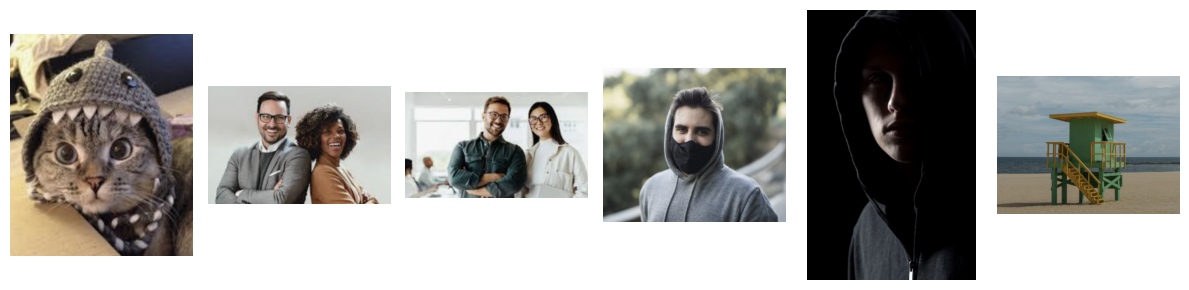

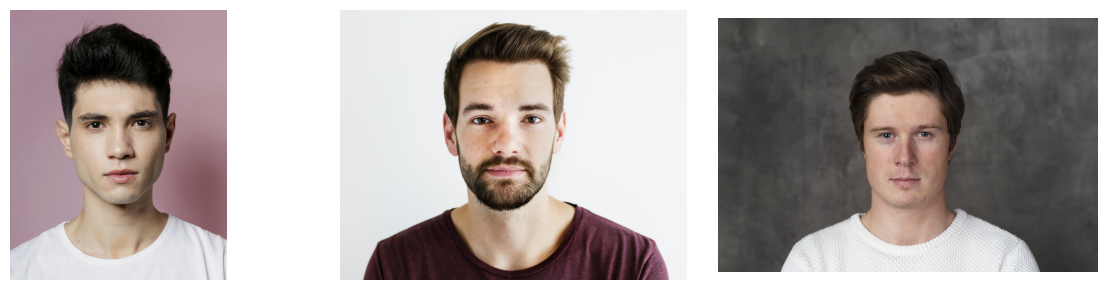

In [33]:
db_embeddings = torch.load("../data/faces/db_embeddings.pt")
new_embeddings = torch.load("../data/faces/new_embeddings.pt")

file_path = '../data/faces/new_paths.npy'
new_paths = np.load(file_path)


def find_invalid_images(new_embeddings, db_embeddings, new_paths, threshold=0.5):
    # Нормализуем эмбеддинги
    db_embeddings = F.normalize(db_embeddings, p=2, dim=1)
    new_embeddings = F.normalize(new_embeddings, p=2, dim=1)

    # Вычисляем косинусное сходство между новыми изображениями и архивными
    similarities = cosine_similarity(new_embeddings.numpy(), db_embeddings.numpy())
    max_similarities = similarities.max(axis=1)

    # Определяем, какие изображения не соответствуют формату
    invalid_mask = max_similarities < threshold
    invalid_paths = new_paths[invalid_mask]

    return invalid_paths, max_similarities


def display_images(image_paths, figsize=(12, 3)):
    """
    Отображает изображения из списка путей в одну строку (горизонтально)
    """
    num_images = len(image_paths)

    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    fig.subplots_adjust(wspace=0.2)

    # Отображаем изображения
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = Image.open(image_paths[i])
            ax.imshow(img)
            ax.axis('off')

    plt.tight_layout()
    plt.show()
   

invalid_images, similarities = find_invalid_images(new_embeddings, 
             db_embeddings, new_paths, threshold=0.68)

# Визуализируем фото, не прошедшие проверку
display_images(invalid_images)
# Визуализируем фото, прошедшие проверку
display_images(list(set(new_paths).difference(invalid_images))) 